# How can machine learning be applied to classify site stability of carbon storage basins?

In my second subquestion, I use a dataset from Miocic et al. (2016) of global CGS basins. 

# Import Necessary Packages

In [1]:
#basic operations
import pandas as pd
import numpy as np

#PCA
from sklearn.decomposition import PCA

#plotting
import matplotlib.pyplot as plt
import seaborn as sns

#modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, recall_score, accuracy_score 
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

#warnings
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

# Read in Data from Miocic et al. (2016)
I read in the dataframe that I previously created using Miocic et al. (2016).

In [2]:
miocic = pd.read_csv('miocic_df.csv').set_index('Name')
miocic 

,Densities,Leakage,Reservoir thickness (Gross),Seal thickness,Depth,Temperature,Pressure,Trapmech_structural,Trapmech_stratigraphic,Structural_fault,...,Res_sandstone,Res_carbonates,Res_other,Carbonate_limestone,Carbonate_dolomite,Seal_shale,Seal_evaporite,Seal_other,Stacked_yes,Stacked_nan
Name,,,,,,,,,,,,,,,,,,,,,
Jackson Dome,654.6,0.0,214.4,900.0,4660.00,150.000000,491.6,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
El Trapial Field,141.0,0.0,163.4,210.0,1234.00,56.000000,64.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.8,0.2,0.4,0.0,1.0
Messokampos,0.9,1.0,260.0,10.0,500.00,25.000000,0.5,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Budafa Field,451.6,0.0,100.0,420.0,3300.00,164.000000,295.0,1.0,0.2,0.4,...,1.0,0.0,0.0,0.0,0.0,1.0,0.2,0.2,1.0,0.0
DF1-1 Field,378.3,0.0,190.4,210.0,1365.00,70.000000,129.2,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Turaco, Albertine Graben",769.4,0.0,166.0,266.0,2500.00,87.667043,288.8,0.8,0.2,0.4,...,1.0,0.0,0.0,0.0,0.0,0.8,0.2,0.0,1.0,0.0
DF29-1,465.2,0.0,80.0,300.0,1837.00,92.000000,186.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
L22-1,423.8,0.0,121.7,300.0,1498.00,78.000000,138.8,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Principal Component Analysis

Principal Component Analysis (PCA) is a method of unsupervised machine learning which maximizes variance and important information from a table by creating principal components of a linear combination of features. This is typically performed on inter-correlated data with linearly dependent features.

I perform PCA using the data’s features and withhold data labels (leakage presence/absence). This enables the model to reveal inherent structures within the data to potentially partition the sites based on certain characteristics without explicit training.

In order to perform PCA, I need to reorient the data to be a 61 x 22 numpy array. I also only want to include the data, not the Leakage information. I create miocic_pca_arr which is a numpy array of the miocic dataframe only containing feature information, not leakage/stability.

In [3]:
miocic_pca = miocic.drop(columns= 'Leakage')
miocic_pca_arr = miocic_pca.to_numpy()
miocic_pca_arr.shape

(61, 22)

Next, I calculate the mean and standard deviation across each column/feature in order to center and standardize the numpy array. This is essential in PCA because it prevents percieved feature importance due to size of numbers alone. This way, features are standardized across different scales, allowing PCA to identify key features not considering conflated number values.

In [4]:
miocic_mean = np.mean(miocic_pca_arr, axis=0)
miocic_std = np.std(miocic_pca_arr, axis=0)
miocic_standardized = (miocic_pca_arr - miocic_mean) / miocic_std

In [5]:
pca = PCA()
pca.fit(miocic_standardized)
miocic_2d= pca.transform(miocic_standardized)[:, :2]

## Visualize Principal Components
In order to visualize the PCA, I plot the transformed data using the first two principal components as the x and y axis. I color the data based on the Leakage target variable.

In [6]:
hue = miocic['Leakage'].map({0: 'No Leakage (Stable)',
                            1: 'Leakage Detected (Insecure)',
                            2: 'Ambiguous'})
palette = {'No Leakage (Stable)': '#1f77b4', # '#4C72B0', # '#1f77b4'
           'Leakage Detected (Insecure)': 'red',
           'Ambiguous': '#4D4D4D'}

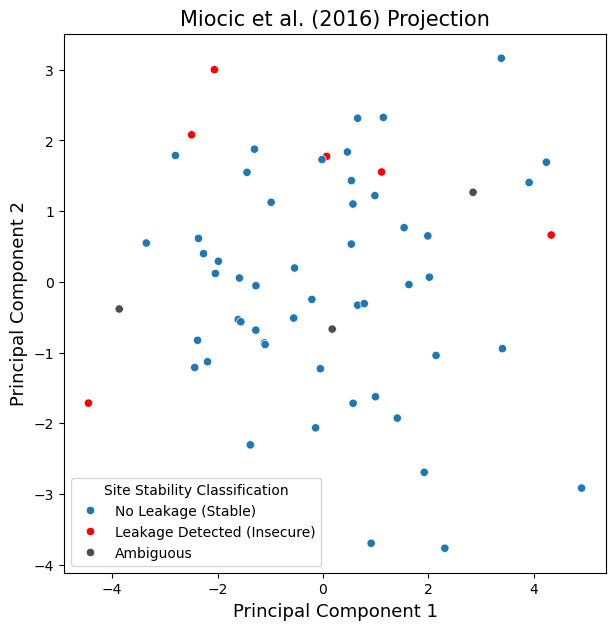

In [27]:
plt.figure(figsize = (7,7))
plt.title("Miocic et al. (2016) Projection", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=13)
plt.ylabel("Principal Component 2", fontsize=13)
ax = sns.scatterplot(x = miocic_2d[:, 0], y = miocic_2d[:, 1], hue = hue, palette = palette)
ax.legend(title='Site Stability Classification');

Site Stability Class seems uncorrelated with Principal Component 1 and Principal Component 2. A majority of insecure sites  have large Principal Component 2 values; however, stable sites are spatially distributed around insecure sites. PCA fails to spatially separate sites based on site stability. 

## PCA Analysis
To further determine the success of the PCA, I calculate the percent of total dataset variance captured by the first two principal components.

In [8]:
print(f'Percent Variance Captured: {sum(pca.explained_variance_ratio_[0:2])*100}')

Percent Variance Captured: 31.11081781438656


Only 31% of variance is captured using the first two principal components, demonstrating large variance loss.
## Scree Plot
Next, I create a Scree Plot to visualize the weight of each principal component.

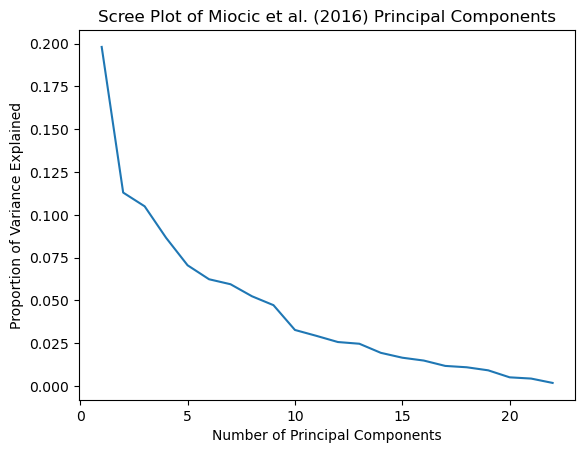

In [9]:
x= np.arange(1, 23)
y = pca.explained_variance_ratio_
plt.plot(x, y)
plt.xlabel('Number of Principal Components')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot of Miocic et al. (2016) Principal Components')
plt.show()

# Site Stability Classification 
First, I handle basins where leakage detection was inconclusive. Aviso et al. (2019) re-classified these points as leakage. I follow this same conservative approach to avoid removing data and to recognize the concerns that lead the authors to not label the data as secure in the first place.

In [10]:
miocic['Leakage'] = miocic['Leakage'].map({0.0:0.0, 1.0:1.0, 2.0: 1.0})
miocic['Leakage'].value_counts()

Leakage
0.0    52
1.0     9
Name: count, dtype: int64

I define X and y and create a stratified 70:30 train test split, ensuring that both classes are present in the train and test splits.

In [11]:
#define X (all data except for leakage classification)
X = miocic.drop(columns='Leakage')

#define y 
y = miocic['Leakage']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state =22, stratify= y) 

## Random Forest Classifier

In [13]:
#without hyperparameter tuning
rf = RandomForestClassifier(random_state=22)
rf.fit(X_train, y_train)
y_pred_rf= rf.predict(X_test)
rf.score(X_test, y_test)

0.8421052631578947

In [14]:
f1_score(y_test, y_pred_rf)

0.0

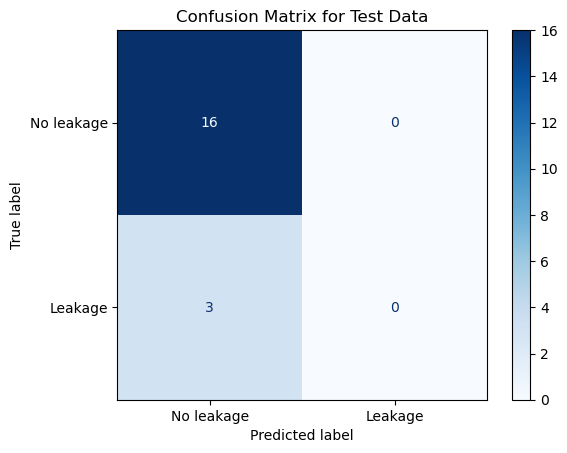

In [15]:
cm = confusion_matrix(y_test, y_pred_rf, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

In [16]:
#model hyperparameter tuning using GridSearchCV and KFold Cross Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=22)
hyperparameters = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 0.5],
    'class_weight': ['balanced', 'balanced_subsample']}
rf= GridSearchCV(
    estimator = RandomForestClassifier(random_state=22),
    param_grid = hyperparameters,
    scoring='f1',
    refit=True, 
    cv=cv,
    return_train_score= True)
#fit model on training data
rf.fit(X_train, y_train)
probs = rf.predict_proba(X_train)[:, 1]

In [17]:
#optimize prediction threshold (GridSearchCV optimizes to 0.5 only) using cross-fold validation
fold_thresholds = []
fold_accuracy = []
fold_f1 = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf.best_estimator_.fit(X_tr, y_tr)
    probs_val = rf.best_estimator_.predict_proba(X_val)[:, 1]
    
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, probs_val)
    f1_scores = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)
    accuracies = []
    for t in thresholds:
        preds = (probs_val >= t).astype(int)
        accuracies.append(accuracy_score(y_val, preds))
    accuracies = np.array(accuracies)
    f1_normalized = f1_scores[:-1] / (f1_scores[:-1].max() + 1e-9)
    accuracy_normalized = accuracies / (accuracies.max() + 1e-9)
    combined_performance = (0.5 * accuracy_normalized) + (0.5 * f1_normalized)
    
    best_t = thresholds[combined_performance.argmax()]
    preds_best = (probs_val >= best_t).astype(int)
    fold_accuracy.append(accuracy_score(y_val, preds_best))
    fold_f1.append(f1_score(y_val, preds_best, zero_division=0))
    fold_thresholds.append(best_t)
    
best_threshold = np.mean(fold_thresholds)

In [18]:
train_probs = rf.predict_proba(X_train)[:, 1]
train_preds_rf = (train_probs >= best_threshold).astype(int)
test_probs = rf.predict_proba(X_test)[:, 1]
test_preds_rf = (test_probs >= best_threshold).astype(int)
    
print('Train Accuracy: ', accuracy_score(y_train, train_preds_rf)) 
print('Mean Validation Accuracy: ', np.mean(fold_accuracy)) 
print('Test Accuracy: ', accuracy_score(y_test,  test_preds_rf))  
print('Train F1 Score: ', f1_score(y_train, train_preds_rf, average='binary', zero_division=0))
print('Mean Validation F1 Score: ', np.mean(fold_f1))
print('Test F1 Score: ', f1_score(y_test,  test_preds_rf,  average='binary', zero_division=0)) 

Train Accuracy:  0.9047619047619048
Mean Validation Accuracy:  0.8333333333333334
Test Accuracy:  0.8421052631578947
Train F1 Score:  0.6666666666666666
Mean Validation F1 Score:  0.611111111111111
Test F1 Score:  0.4


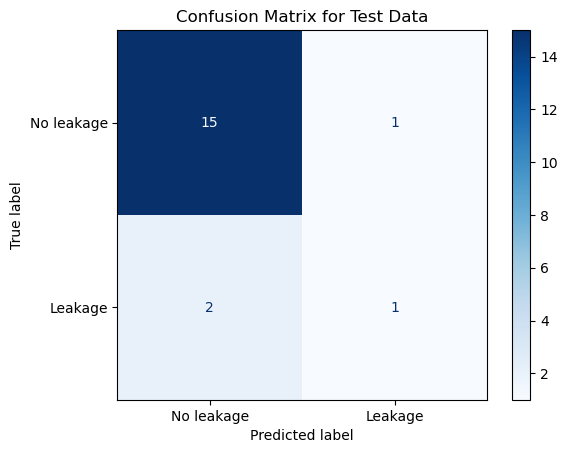

In [19]:
cm = confusion_matrix(y_test, test_preds_rf, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

## Gradient Boosting Classifier

In [20]:
#without hyperparameter tuning
gb = GradientBoostingClassifier(random_state=22)
gb.fit(X_train, y_train)
y_pred_gb= gb.predict(X_test)
gb.score(X_test, y_test)

0.8421052631578947

In [21]:
f1_score(y_test, y_pred_gb)

0.4

In [83]:
#model hyperparameter tuning using GridSearchCV and KFold Cross Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=22)
hyperparameters = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],            
    'learning_rate': [0.05, 0.1],     
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 0.5],
    'subsample': [0.8, 1.0]  }
gb= GridSearchCV(
    estimator = GradientBoostingClassifier(random_state=22),
    param_grid = hyperparameters,
    scoring='f1',
    refit=True,
    cv=cv,
    n_jobs=-1,
    return_train_score= True)
#fit model on training data
gb.fit(X_train, y_train)
train_probs_gb = gb.predict_proba(X_train)[:, 1]

In [84]:
#optimize prediction threshold (GridSearchCV optimizes to 0.5 only) using cross-fold validation
fold_thresholds_gb = []
fold_accuracy_gb = []
fold_f1_gb = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    gb.best_estimator_.fit(X_tr, y_tr)
    probs_val = gb.best_estimator_.predict_proba(X_val)[:, 1]
    
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, probs_val)
    f1_scores = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)
    accuracies = []
    for t in thresholds:
        preds = (probs_val >= t).astype(int)
        accuracies.append(accuracy_score(y_val, preds))
    accuracies = np.array(accuracies)
    f1_normalized = f1_scores[:-1] / (f1_scores[:-1].max() + 1e-9)
    accuracy_normalized = accuracies / (accuracies.max() + 1e-9)
    combined_performance = (0.5 * accuracy_normalized) + (0.5 * f1_normalized)
    
    best_t = thresholds[combined_performance.argmax()]
    preds_best = (probs_val >= best_t).astype(int)
    fold_accuracy_gb.append(accuracy_score(y_val, preds_best))
    fold_f1_gb.append(f1_score(y_val, preds_best, zero_division=0))
    fold_thresholds_gb.append(best_t)
    
best_threshold_gb = np.mean(fold_thresholds_gb)

In [85]:
print(fold_f1_gb)

[0.6666666666666666, 0.6666666666666666, 0.6666666666666666]


In [86]:
train_probs_gb = gb.predict_proba(X_train)[:, 1]
train_preds_gb = (train_probs_gb >= best_threshold_gb).astype(int)
test_probs_gb = gb.predict_proba(X_test)[:, 1]
test_preds_gb = (test_probs_gb >= best_threshold_gb).astype(int)
    
print('Train Accuracy: ', accuracy_score(y_train, train_preds_gb)) 
print('Mean Validation Accuracy: ', np.mean(fold_accuracy_gb)) 
print('Test Accuracy: ', accuracy_score(y_test,  test_preds_gb))  
print('Train F1 Score: ', f1_score(y_train, train_preds_gb, average='binary', zero_division=0))
print('Mean Validation F1 Score: ', np.mean(fold_f1_gb))
print('Test F1 Score: ', f1_score(y_test,  test_preds_gb,  average='binary', zero_division=0)) 

Train Accuracy:  0.9523809523809523
Mean Validation Accuracy:  0.9285714285714285
Test Accuracy:  0.8421052631578947
Train F1 Score:  0.8
Mean Validation F1 Score:  0.6666666666666666
Test F1 Score:  0.0


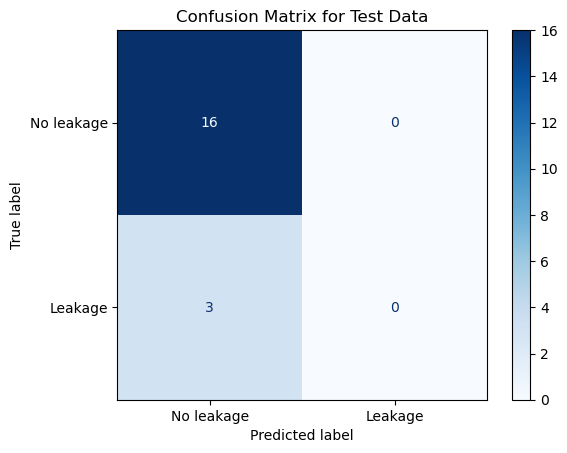

In [87]:
cm = confusion_matrix(y_test, test_preds_gb, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

### Gradient Boosting Using XGBClassifier

In [88]:
xgb = XGBClassifier(random_state=22)
xgb.fit(X_train, y_train)
y_pred_xgb= xgb.predict(X_test)
xgb.score(X_test, y_test)

0.8421052631578947

In [89]:
f1_score(y_test, y_pred_xgb)

0.4

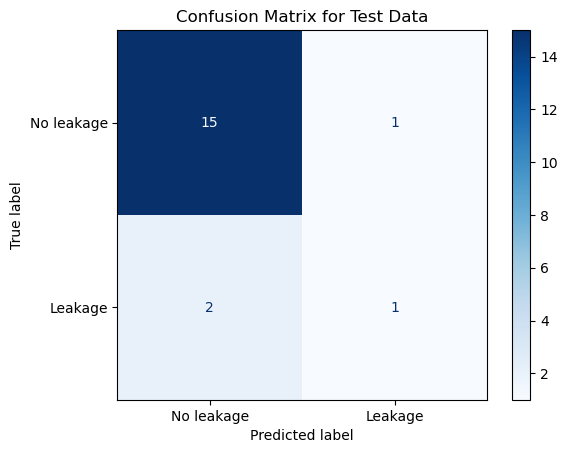

In [90]:
cm = confusion_matrix(y_test, y_pred_xgb, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

In [26]:
#model hyperparameter tuning using GridSearchCV and KFold Cross Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=22)
hyperparameters = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.1, 0.3],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0]}
xgb = GridSearchCV(
    estimator= XGBClassifier(random_state=22),
    param_grid=hyperparameters,
    scoring='f1',
    refit=True,
    cv=cv,
    n_jobs=-1,
    return_train_score=True )

#fit model
xgb.fit(X_train, y_train)

#threshold tuning
fold_accuracy_xgb = []
fold_f1_xgb = []
fold_thresholds_xgb = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    xgb.best_estimator_.fit(X_tr, y_tr)
    probs_val = xgb.best_estimator_.predict_proba(X_val)[:, 1]

    precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, probs_val)
    f1_scores = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)
    best_t = thresholds[f1_scores[:-1].argmax()]
    preds_best = (probs_val >= best_t).astype(int)

    fold_accuracy_xgb.append(accuracy_score(y_val, preds_best))
    fold_f1_xgb.append(f1_score(y_val, preds_best, zero_division=0))
    fold_thresholds_xgb.append(best_t)

best_threshold_xgb = np.mean(fold_thresholds_xgb)

In [27]:
#evaluate
train_probs_xgb = xgb.predict_proba(X_train)[:, 1]
train_preds_xgb = (train_probs_xgb >= best_threshold_xgb).astype(int)
test_probs_xgb = xgb.predict_proba(X_test)[:, 1]
test_preds_xgb = (test_probs_xgb >= best_threshold_xgb).astype(int)

print('Train Accuracy:', accuracy_score(y_train, train_preds_xgb))
print('Mean Validation Accuracy:', np.mean(fold_accuracy_xgb))
print('Test Accuracy:', accuracy_score(y_test, test_preds_xgb))
print('Train F1:', f1_score(y_train, train_preds_xgb, zero_division=0))
print('Mean Validation F1:', np.mean(fold_f1_xgb))
print('Test F1:', f1_score(y_test, test_preds_xgb, zero_division=0))

Train Accuracy: 0.8571428571428571
Mean Validation Accuracy: 0.738095238095238
Test Accuracy: 0.7368421052631579
Train F1: 0.5714285714285714
Mean Validation F1: 0.4904761904761905
Test F1: 0.2857142857142857


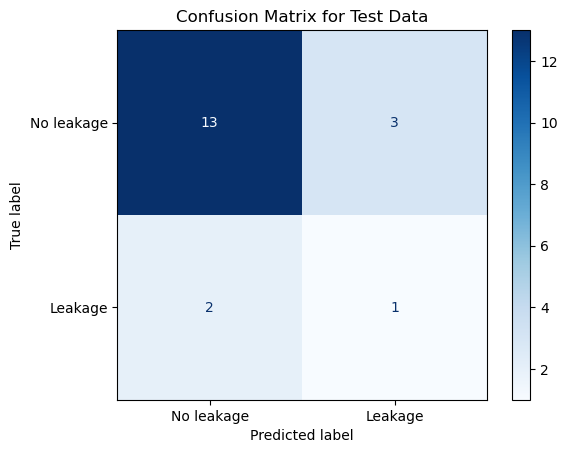

In [93]:
cm = confusion_matrix(y_test, test_preds_xgb, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

For both SkLearn and XGBoost Gradient Boosting Classifiers, the standard classifier without hyperparameter tuning and without threshold tuning performs the best on test data. 

In [23]:
gb = GradientBoostingClassifier(random_state=22)
gb.fit(X_train, y_train)
test_preds_gb= gb.predict(X_test)
train_preds_gb = gb.predict(X_train)

fold_accuracy_gb = []
fold_f1_gb = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    gb.fit(X_tr, y_tr)
    preds = gb.predict(X_val)

    fold_accuracy_gb.append(accuracy_score(y_val, preds))
    fold_f1_gb.append(f1_score(y_val, preds, zero_division=0))
    
print('Train Accuracy: ', accuracy_score(y_train, train_preds_gb)) 
print('Mean Validation Accuracy: ', np.mean(fold_accuracy_gb)) 
print('Test Accuracy: ', accuracy_score(y_test,  test_preds_gb))  
print('Train F1 Score: ', f1_score(y_train, train_preds_gb, average='binary', zero_division=0))
print('Mean Validation F1 Score: ', np.mean(fold_f1_gb))
print('Test F1 Score: ', f1_score(y_test,  test_preds_gb,  average='binary', zero_division=0)) 

Train Accuracy:  1.0
Mean Validation Accuracy:  0.8571428571428571
Test Accuracy:  0.8421052631578947
Train F1 Score:  1.0
Mean Validation F1 Score:  0.16666666666666666
Test F1 Score:  0.4


However, due to the standard GradientBoostingClassifier's extremely low validation F1 score, I belive that XGBoost's model will be more generalizable.

## Multi Layer Perceptron

In [29]:
#hyperparameter tuning with GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        random_state=22,
        max_iter=2000,
        early_stopping=True,
        n_iter_no_change=20,
        learning_rate='adaptive' )) ])

hyperparameters = {
    'mlp__hidden_layer_sizes': [(30,), (50,), (100,), (50, 25), (100, 50)],
    'mlp__alpha': [0.001, 0.01, 0.1],
    'mlp__learning_rate_init': [0.001, 0.01]}

nn = GridSearchCV(
    estimator=pipe,
    param_grid=hyperparameters,
    scoring='f1',
    refit=True,
    cv=cv,
    n_jobs=-1,
    return_train_score=True)

#fit the model
nn.fit(X_train, y_train)

#threshold tuning
fold_accuracy_nn = []
fold_f1_nn = []
fold_thresholds_nn = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    nn.best_estimator_.fit(X_tr, y_tr)
    probs_val = nn.best_estimator_.predict_proba(X_val)[:, 1]

    precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, probs_val)
    f1_scores = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)

    best_t = thresholds[f1_scores[:-1].argmax()]
    preds_best = (probs_val >= best_t).astype(int)

    fold_accuracy_nn.append(accuracy_score(y_val, preds_best))
    fold_f1_nn.append(f1_score(y_val, preds_best, zero_division=0))
    fold_thresholds_nn.append(best_t)

best_threshold_nn = np.mean(fold_thresholds_nn)

train_probs_nn = nn.predict_proba(X_train)[:, 1]
train_preds_nn = (train_probs_nn >= best_threshold_nn).astype(int)
test_probs_nn = nn.predict_proba(X_test)[:, 1]
test_preds_nn = (test_probs_nn >= best_threshold_nn).astype(int)

print('Train Accuracy:', accuracy_score(y_train, train_preds_nn))
print('Mean Validation Accuracy:', np.mean(fold_accuracy_nn))
print('Test Accuracy:', accuracy_score(y_test, test_preds_nn))
print('Train F1:', f1_score(y_train, train_preds_nn, zero_division=0))
print('Mean Validation F1:', np.mean(fold_f1_nn))
print('Test F1:', f1_score(y_test, test_preds_nn, zero_division=0))

Train Accuracy: 0.8095238095238095
Mean Validation Accuracy: 0.7055555555555555
Test Accuracy: 0.7894736842105263
Train F1: 0.42857142857142855
Mean Validation F1: 0.5444444444444445
Test F1: 0.3333333333333333


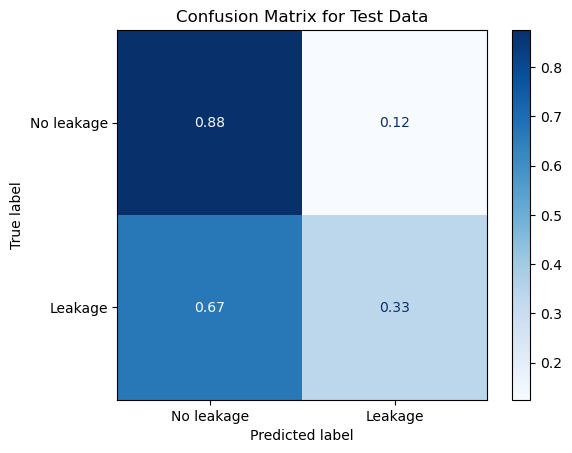

In [99]:
cm = confusion_matrix(y_test, test_preds_nn, labels=[0,1], normalize = 'true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

# Combined Plots for Thesis

## PCA

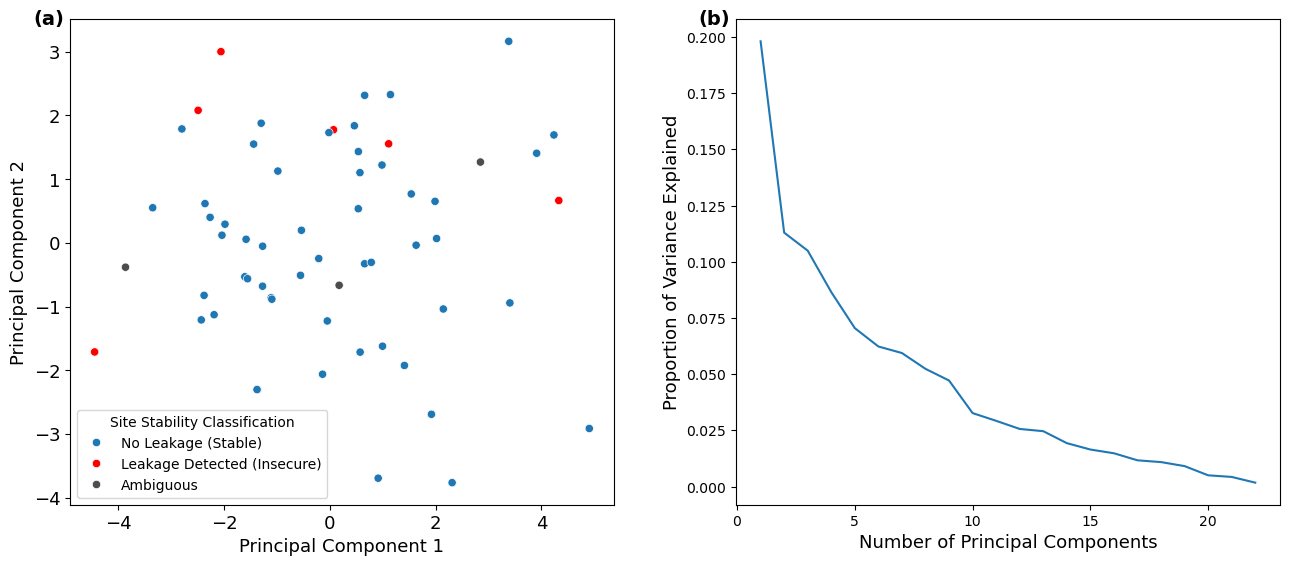

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- Left: PCA Scatter ---
sns.scatterplot(
    x=miocic_2d[:, 0],
    y=miocic_2d[:, 1],
    hue=hue,
    palette=palette,
    ax=axes[0] )
axes[0].set_xlabel("Principal Component 1", fontsize=13)
axes[0].set_ylabel("Principal Component 2", fontsize=13)
axes[0].legend(title='Site Stability Classification')
axes[0].tick_params(axis='both', labelsize=13)

# Panel label (a)
axes[0].text(
    -0.01, 1.02, "(a)",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top',
    ha='right')

# --- Right: Scree Plot ---
x= np.arange(1, 23)
y = pca.explained_variance_ratio_
axes[1].plot(x, y)
axes[1].set_xlabel('Number of Principal Components', fontsize=13)
axes[1].set_ylabel('Proportion of Variance Explained', fontsize=13)
axes[0].tick_params(axis='both', labelsize=13)

# Panel label (b)
axes[1].text(
    -0.01, 1.02, "(b)",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top',
    ha='right')

fig.subplots_adjust(wspace= 2.5)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.savefig("Figure_2.png", dpi=300, bbox_inches='tight')
plt.show()

## Confusion Matrices

In [24]:
def confusion(test_preds, model_name, ax=None):
    cm = confusion_matrix(y_test, test_preds, labels=[0,1], normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage', 'Leakage'])

    if ax is None:
        fig, ax = plt.subplots()
    
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
    ax.set_title(model_name)

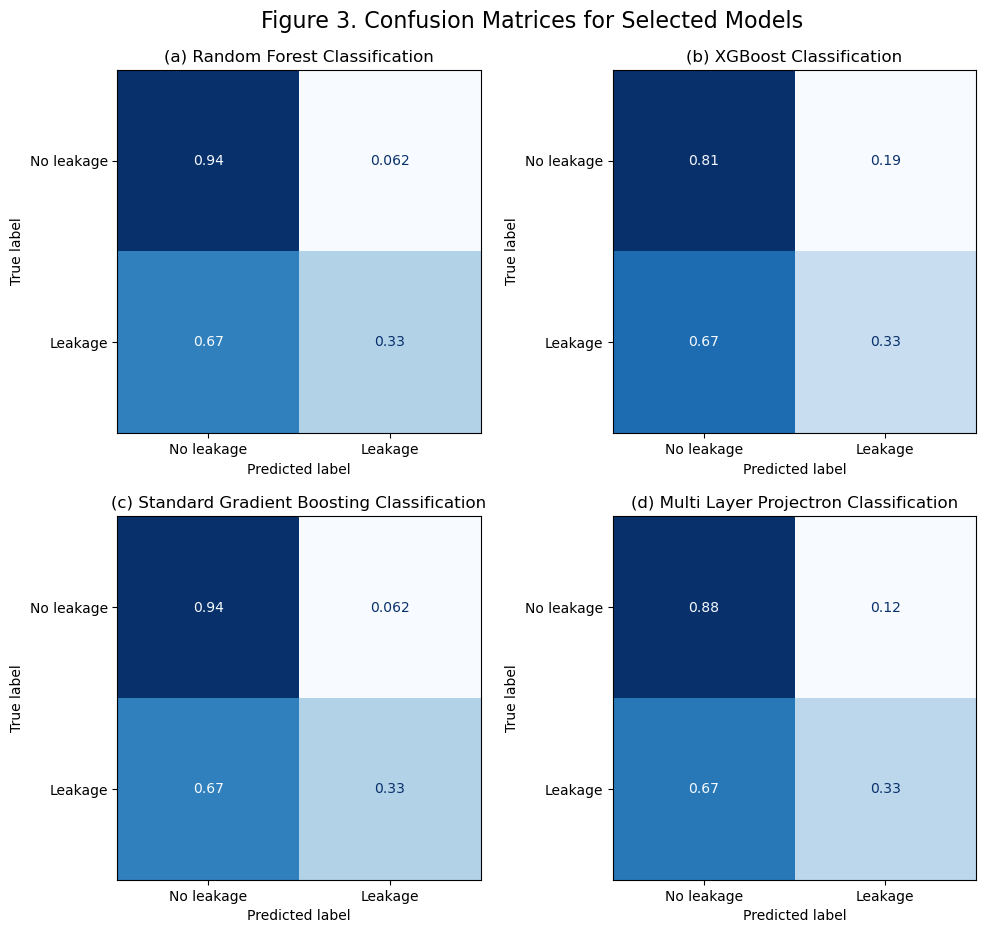

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

confusion(test_preds_rf, '(a) Random Forest Classification', ax=axes[0,0])
confusion(test_preds_xgb, '(b) XGBoost Classification', ax=axes[0,1])
confusion(test_preds_gb, '(c) Standard Gradient Boosting Classification', ax=axes[1,0])
confusion(test_preds_nn, '(d) Multi Layer Projectron Classification', ax=axes[1,1])

fig.suptitle('Figure 3. Confusion Matrices for Selected Models', fontsize=16)
plt.subplots_adjust(wspace=0.14, top=0.92, hspace=0.23)
plt.savefig("Figure_3.png", dpi=300, bbox_inches='tight')

plt.show()